In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv('./dataSet/new.csv')
df = pd.DataFrame(data)

df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

(2240, 29)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [4]:
for col in df.columns:
    temp = df[col].isnull().sum()
    if temp > 0 :
        print(f'the {col} columns has {temp} null values')

the Income columns has 24 null values


In [5]:
df = df.dropna()
print("Total values in the dataset after removing the null values:", len(df))

Total values in the dataset after removing the null values: 2216


In [6]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
parts = df['Dt_Customer'].str.split('-',n=3,expand=True)
print(parts)

       0   1     2
0     04  09  2012
1     08  03  2014
2     21  08  2013
3     10  02  2014
4     19  01  2014
...   ..  ..   ...
2235  13  06  2013
2236  10  06  2014
2237  25  01  2014
2238  24  01  2014
2239  15  10  2012

[2216 rows x 3 columns]


In [9]:
df['Day'] = parts[0].astype('int')
df['Month'] = parts[1].astype('int')
df['Year'] = parts[2].astype('int')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Day,Month,Year
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,4,9,2012
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,8,3,2014
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,21,8,2013
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,10,2,2014
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,19,1,2014


In [10]:
df.drop(['Z_CostContact', 'Z_Revenue', 'Dt_Customer'],
        axis=1,
        inplace=True)
print('deleted some columns!')

deleted some columns!


In [11]:
floats, objects = [],[]
for col in df.columns:
    if df[col].dtype == 'object':
        objects.append(col)
    elif df[col].dtype == 'float':
        floats.append(col)

print(floats)
print(objects)      

['Income']
['Education', 'Marital_Status']


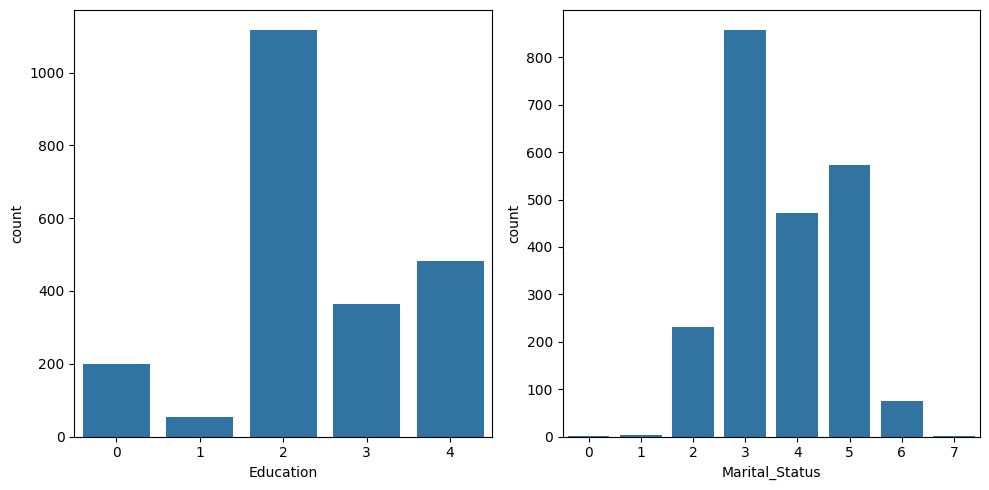

In [36]:
plt.figure(figsize=(10,5))

for i, col in enumerate(objects):
    plt.subplot(1, 2, i + 1) 
    sb.countplot(x=df[col])

plt.tight_layout()
plt.savefig("objects.png")
plt.show()

In [13]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
for col in objects:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col]) 


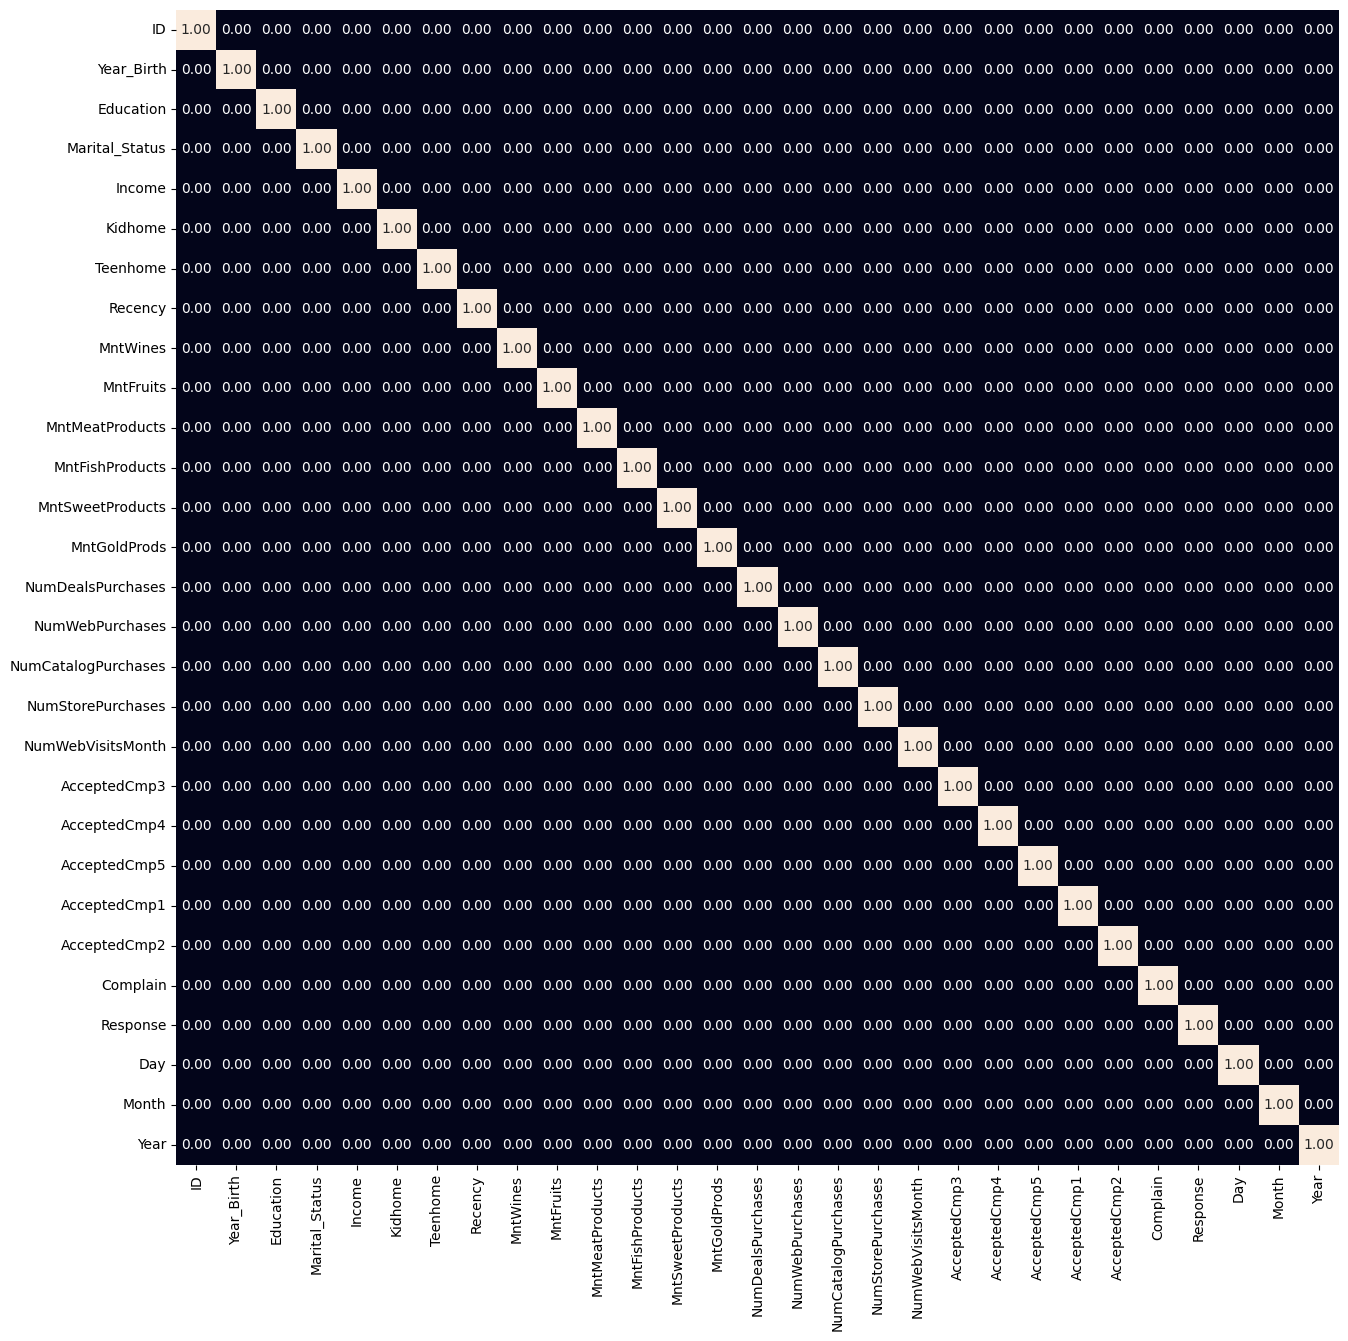

In [35]:
plt.figure(figsize=(15,15))
sb.heatmap(df.corr() > 0.8,annot=True,fmt='.2f',cbar= False)
plt.savefig("correlaion.png")
plt.show()

In [16]:
scaler = StandardScaler()
data = scaler.fit_transform(df)
print(data)

[[-0.0198093  -0.98644293 -0.35052725 ... -1.3267421   0.72650098
  -1.50034282]
 [-1.05100909 -1.23680074 -0.35052725 ... -0.8713424  -0.99319941
   1.41739276]
 [-0.44552551 -0.31882209 -0.35052725 ...  0.60870665  0.43988425
  -0.04147503]
 ...
 [ 0.51764587  1.01641959 -0.35052725 ...  1.06410635 -1.56643287
   1.41739276]
 [ 0.81469298 -1.06989553  0.53924181 ...  0.95025642 -1.56643287
   1.41739276]
 [ 1.17484335 -1.23680074  1.42901088 ... -0.07439291  1.01311772
  -1.50034282]]


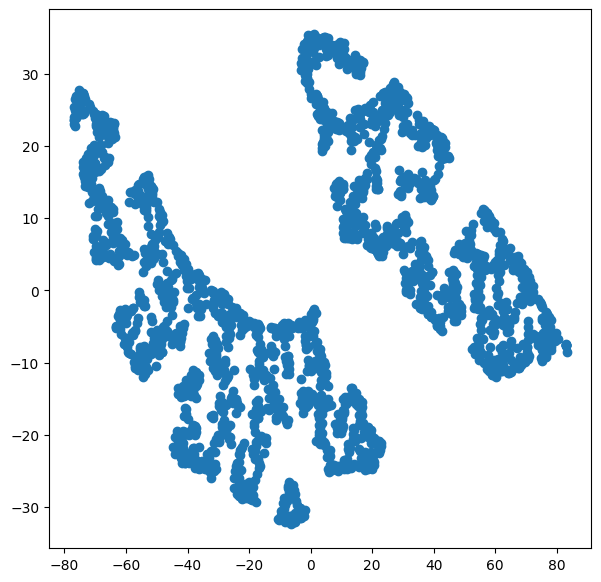

In [34]:
from sklearn.manifold import TSNE
model = TSNE(n_components = 2,random_state = 42)
tsne_data = model.fit_transform(df)
plt.figure(figsize=(7,7))
plt.scatter(tsne_data[:,0],tsne_data[:,1])
plt.savefig("tsne_scatter_plot.png")
plt.show()

In [24]:
from sklearn.cluster import KMeans
error = []
for n_clusters in range(1,21):
    model = KMeans(init='k-means++',
                   n_clusters = n_clusters,
                   max_iter=500,
                   random_state = 22)
    model.fit(df)
    error.append(model.inertia_) # here inertia is the sum of sqared distances within the clusters

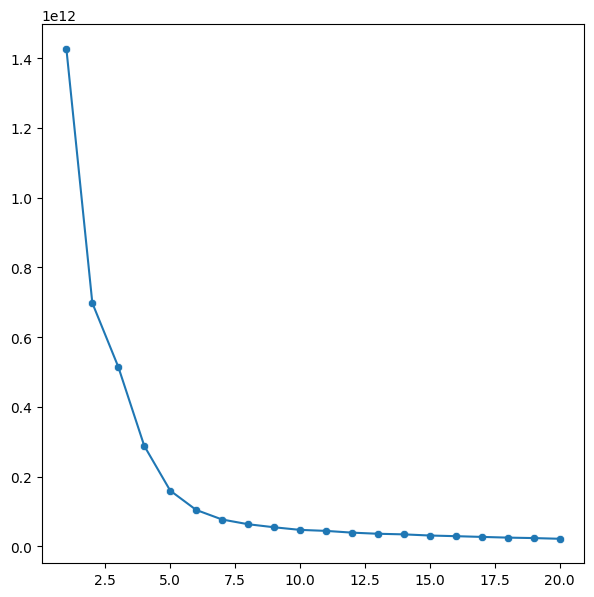

In [33]:
plt.figure(figsize=(7,7))
sb.lineplot(x=range(1,21),y=error)
sb.scatterplot(x=range(1,21),y=error)
plt.savefig("k-means__plot.png")
plt.show()

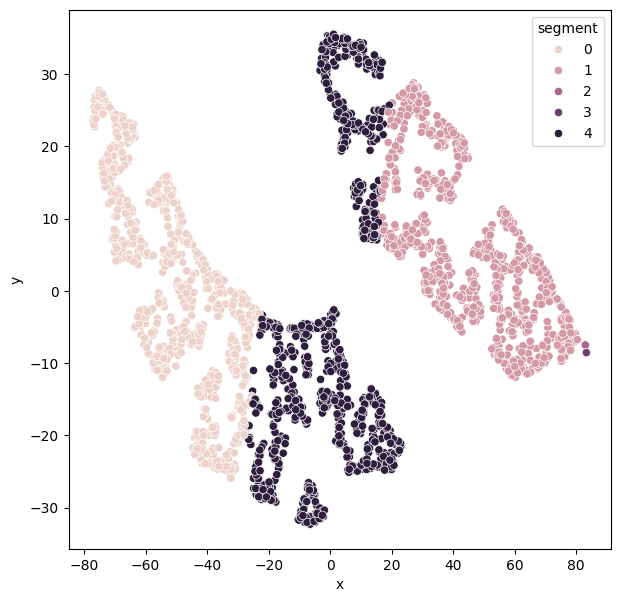

In [32]:
from sklearn.cluster import KMeans
model = KMeans(
    init='k-means++',
    n_clusters=5,
    max_iter=500,
    random_state=22
)
segments = model.fit_predict(df)
plt.figure(figsize=(7,7))
df_tsne = pd.DataFrame({
    'x': tsne_data[:,0],
    'y': tsne_data[:,1],
    'segment': segments
})
sb.scatterplot(x='x', y='y', hue='segment', data=df_tsne)
plt.savefig("segmented_cluster_plot.png")
plt.show()

In [ ]:
# Here we can see that we have divide customers into 5 clusters and based on these clusters we can target
# customers with same purchasing behaviour much better. We can give personalised ads and can make informed 
# decision about business for better growth.